In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
# Step 2: Interactive File Upload
# This matches the Colab upload widget in your reference notebook
uploaded = files.upload()

Saving Student_Performance.csv to Student_Performance.csv


In [3]:
# Step 3: Load and Inspect the Dataset
# Loading the provided Student_Performance.csv
df = pd.read_csv('Student_Performance.csv')

In [4]:
print("First 5 Rows of the Dataset:")
print(df.head())

First 5 Rows of the Dataset:
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


In [5]:
print("\nDataset Shape:", df.shape)
print("\nColumns:", df.columns)


Dataset Shape: (10000, 6)

Columns: Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')


In [6]:
# Step 4: Data Preprocessing
# Your notebook handles categorical variables using get_dummies with drop_first=True
# We apply this to 'Extracurricular Activities'
df = pd.get_dummies(df, drop_first=True)

In [7]:
print("\nDataset after One-Hot Encoding:")
print(df.head())


Dataset after One-Hot Encoding:
   Hours Studied  Previous Scores  Sleep Hours  \
0              7               99            9   
1              4               82            4   
2              8               51            7   
3              5               52            5   
4              7               75            8   

   Sample Question Papers Practiced  Performance Index  \
0                                 1               91.0   
1                                 2               65.0   
2                                 2               45.0   
3                                 2               36.0   
4                                 5               66.0   

   Extracurricular Activities_Yes  
0                            True  
1                           False  
2                            True  
3                            True  
4                           False  


In [8]:
# Step 5: Define Features (X) and Target (y)
# Following the PDF's goal: predict Performance Index using all other factors
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

In [9]:
print("\nIndependent Variables (X) Shape:", X.shape)
print("Dependent Variable (y) Shape:", y.shape)


Independent Variables (X) Shape: (10000, 5)
Dependent Variable (y) Shape: (10000,)


In [10]:
# Step 6: Split the Dataset
# We use a 70-30 split with random_state=0 to match your notebook's style
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

print("\nTraining Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)


Training Set Shape: (7000, 5)
Testing Set Shape: (3000, 5)


In [11]:
# Step 7: Build and Train the Multiple LR Model
# Creating the regressor as shown in the presentation and notebook
regressor = LinearRegression()
regressor.fit(X_train, y_train)

print("\nModel Intercept (beta_0):", regressor.intercept_)
print("Model Coefficients (beta_n):", regressor.coef_)


Model Intercept (beta_0): -34.0621202365709
Model Coefficients (beta_n): [2.84957996 1.01941699 0.47426223 0.18631283 0.62178694]


In [12]:
# Step 8: Predictions
y_pred = regressor.predict(X_test)

print("\nFirst 5 Predicted Performance Indices:")
print(y_pred[:5])


First 5 Predicted Performance Indices:
[50.46443613 53.10077726 78.27207629 25.36296322 67.43269493]


In [13]:
# Step 9: Model Evaluation
# Calculating performance metrics as defined in your project template
print("\n--- Model Evaluation ---")
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))


--- Model Evaluation ---
R2 Score: 0.9888065859708454
Mean Absolute Error (MAE): 1.5950954457162958
Mean Squared Error (MSE): 4.039519191698849


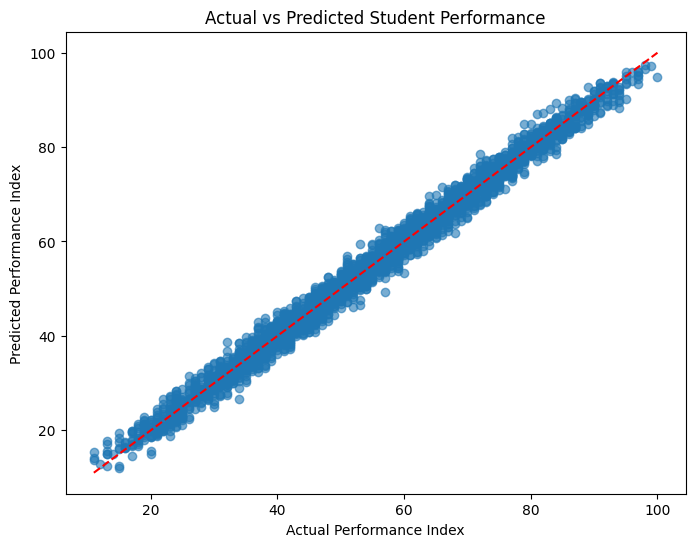

In [14]:
# Step 10: Visualizing the Results
# Plotting Actual vs Predicted values to assess fit
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted Student Performance")
# Adding a reference line for perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()